# Zonal statistics on the burned-area raster

Summarise the burned-area mask (from notebook 06) over the asset zones (from notebook 04): align their CRS, rasterize the asset polygons onto the burned raster's grid, and compute per-zone statistics with `xrspatial.zonal_stats`. Inputs are read from `../outputs/`.

## 1. Load the data

In [1]:
# Load the burned-area mask
import rioxarray
burned = rioxarray.open_rasterio("../outputs/burned.tif")

# Load the asset polygons
import geopandas as gpd
assets = gpd.read_file("../outputs/assets.gpkg")

## 2. Align the datasets

In [2]:
print(assets.crs)
print(burned.rio.crs)

EPSG:4326
EPSG:32635


In [3]:
assets = assets.to_crs(burned.rio.crs)

## 3. Rasterize the vector data

In [4]:
geom = assets[["geometry", "code"]].values.tolist()
geom

[[<POLYGON ((602761.27 4013139.375, 602764.522 4013072.287, 602771.476 4012998...>,
  1],
 [<POLYGON ((602779.808 4013298.838, 602772.497 4013266.01, 602768.577 4013242...>,
  1],
 [<POLYGON ((602594.855 4012962.661, 602593.423 4012983.028, 602588.485 401302...>,
  1],
 [<POLYGON ((603065.242 4013113.961, 603111.593 4013104.016, 603316.359 401306...>,
  1],
 [<POLYGON ((604667.306 4012868.545, 604666.966 4012867.076, 604652.425 401280...>,
  1],
 [<POLYGON ((604695.865 4013113.124, 604697.515 4013074.157, 604697.598 401307...>,
  1],
 [<POLYGON ((602733.338 4013063.75, 602724.281 4013065.604, 602716.417 4013066...>,
  1],
 [<POLYGON ((602715.649 4013128.546, 602715.964 4013132.105, 602717.674 401314...>,
  1],
 [<POLYGON ((602698.646 4013255.507, 602704.483 4013253.389, 602712.799 401324...>,
  1],
 [<POLYGON ((602628.876 4013090.757, 602621.48 4013093.659, 602613.414 4013097...>,
  1],
 [<POLYGON ((602761.308 4013148.291, 602760.414 4013139.116, 602758.626 401313...>,
  1],
 [<POLYGON

In [5]:
burned.shape

(1, 4523, 4828)

In [6]:
burned_squeeze = burned.squeeze()
burned_squeeze.shape

(4523, 4828)

In [7]:
from rasterio import features
assets_rasterized = features.rasterize(
    geom, out_shape=burned_squeeze.shape, transform=burned.rio.transform()
)
assets_rasterized

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(4523, 4828))

## 4. Perform zonal statistics

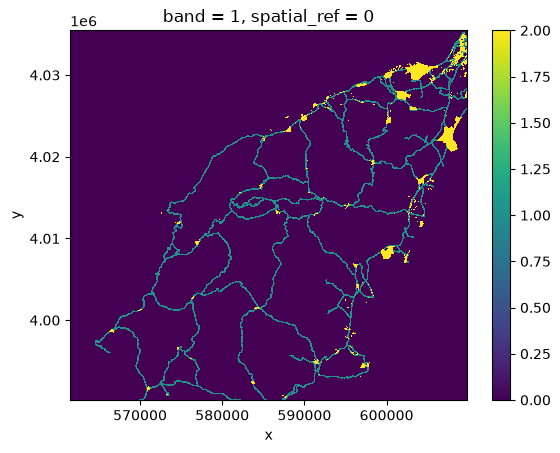

In [8]:
assets_rasterized_xarr = burned_squeeze.copy()
assets_rasterized_xarr.data = assets_rasterized
assets_rasterized_xarr.plot()

In [9]:
from xrspatial import zonal_stats
stats = zonal_stats(assets_rasterized_xarr, burned_squeeze)
stats

,zone,mean,max,min,sum,std,var,count,majority
0,0,0.023504,1.0,0.0,485164.0,0.151498,0.022952,20641610.0,0.0
1,1,0.010361,1.0,0.0,9634.0,0.101259,0.010253,929853.0,0.0
2,2,0.000004,1.0,0.0,1.0,0.001940,0.000004,265581.0,0.0
